In [3]:
import fitsio
import numpy as np
import matplotlib.pyplot as plt

In [54]:
COLLECTED_PATH = (
    "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/"
    "deepCoadd_anacal_v2/m2_m0_collected_zbest.fits"
)


In [55]:
# Load pre-computed per-object arrays (produced by collect_m2_m0.py)
d = fitsio.read(COLLECTED_PATH)
m0_cut = d["m0"].astype(np.float64)
m2_cut = d["m2"].astype(np.float64)
w = d["wsel"].astype(np.float64)
# Pre-averaged shear response: (de1/dg1 + de2/dg2) / 2
resp_per_obj = d["resp"].astype(np.float64)
# Weight-derivative correction: (e1*dwsel/dg1 + e2*dwsel/dg2) / 2
dw_resp_per_obj = d["dw_resp"].astype(np.float64)
e1 = d["e1"].astype(np.float64)
e2 = d["e2"].astype(np.float64)
trace_cut = m2_cut / m0_cut
print(f"Loaded {len(m0_cut)} objects")

Loaded 37120541 objects


In [69]:
# 2D grid with log-spaced bins (per-bin mean of unweighted response)
m0_edges_log = np.logspace(np.log10(2), np.log10(1500), ngrid + 1)
trace_edges_log = np.logspace(np.log10(0.05), np.log10(3.0), ngrid + 1)

i_m0_log = np.digitize(m0_cut, m0_edges_log) - 1
i_tr_log = np.digitize(trace_cut, trace_edges_log) - 1

resp_only_grid_log = np.full((ngrid, ngrid), np.nan)
count_grid_log = np.zeros((ngrid, ngrid), dtype=int)
m0_center_log = np.zeros((ngrid, ngrid))
trace_center_log = np.zeros((ngrid, ngrid))

for ix in range(ngrid):
    for iy in range(ngrid):
        sel = (i_m0_log == ix) & (i_tr_log == iy)
        n = np.sum(sel)
        count_grid_log[ix, iy] = n
        if n < 10:
            continue
        m0_center_log[ix, iy] = np.exp(np.mean(np.log(m0_cut[sel])))
        trace_center_log[ix, iy] = np.exp(np.mean(np.log(trace_cut[sel])))
        resp_only_grid_log[ix, iy] = np.mean(resp_per_obj[sel])

print("Log-spaced m0 edges:", np.round(m0_edges_log, 2))
print("Log-spaced m2/m0 edges:", np.round(trace_edges_log, 4))
print("Counts per bin:")
print(count_grid_log)


Log-spaced m0 edges: [   2.      4.58   10.47   23.94   54.77  125.3   286.63  655.71 1500.  ]
Log-spaced m2/m0 edges: [0.05   0.0834 0.1392 0.2322 0.3873 0.6461 1.0779 1.7983 3.    ]
Counts per bin:
[[  40056  116541  338548  750551  967746  475260   39756      33]
 [ 240061  766659 2216879 4534198 5604250 2705081  222842     153]
 [ 135613  351941 1145388 2579910 3644301 2186447  207221     208]
 [  66740   88680  350502 1073754 1759474 1346700  166346     200]
 [  38025   28653   83486  398888  817081  652450  110552     208]
 [  13231    8201   12486   99431  357726  227738   30239      40]
 [    407     355     549    6108   73113   36256     968       1]
 [      0       1       0       2    1108    1193       6       0]]


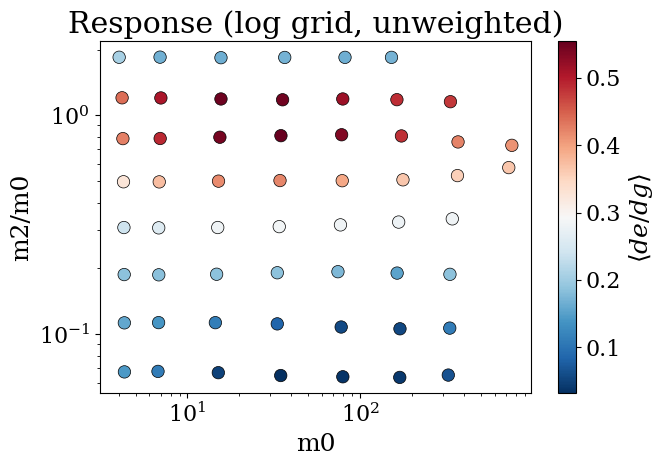

In [70]:
# Scatter plot of the unweighted response on the log grid
valid_log = ~np.isnan(resp_only_grid_log)
resp_flat_log = resp_only_grid_log[valid_log]
m0_flat_log = m0_center_log[valid_log]
trace_flat_log = trace_center_log[valid_log]

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    m0_flat_log, trace_flat_log, c=resp_flat_log, s=80,
    cmap="RdBu_r", edgecolors="k", linewidths=0.5,
)
plt.colorbar(sc, ax=ax, label=r"$\langle de/dg \rangle$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("m0")
ax.set_ylabel("m2/m0")
ax.set_title("Response (log grid, unweighted)")
plt.tight_layout()
plt.show()


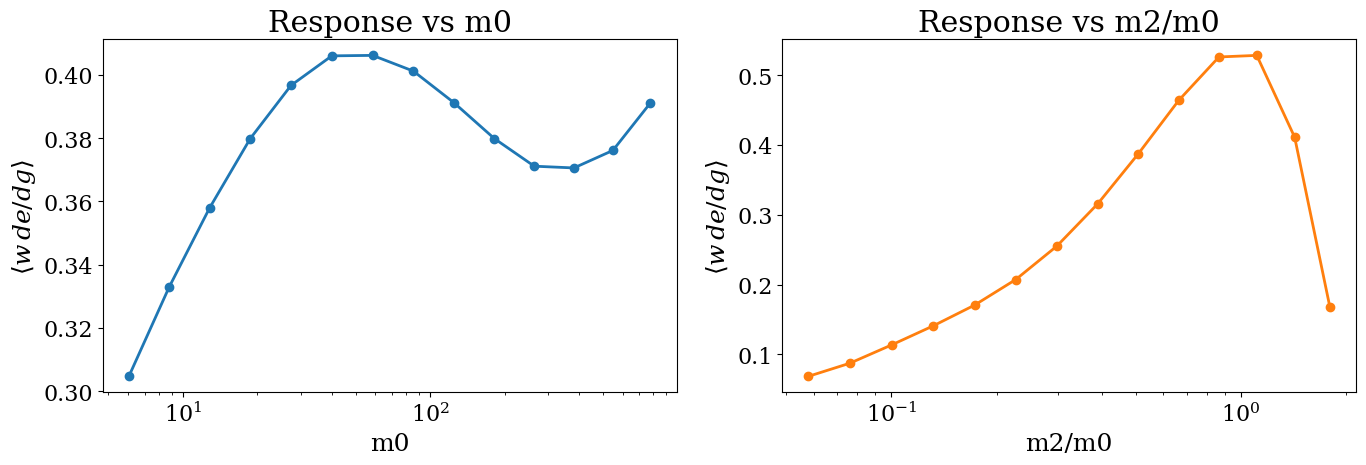

In [71]:
# 1D response plots: marginalize over one axis
nbins_1d = 15
m0_edges_1d = np.logspace(np.log10(5), np.log10(1500), nbins_1d + 1)
i_m0_1d = np.digitize(m0_cut, m0_edges_1d) - 1

resp_vs_m0 = np.full(nbins_1d, np.nan)
m0_centers_1d = np.full(nbins_1d, np.nan)
count_m0 = np.zeros(nbins_1d, dtype=int)

for ib in range(nbins_1d):
    sel = i_m0_1d == ib
    n = np.sum(sel)
    count_m0[ib] = n
    if n < 100:
        continue
    m0_centers_1d[ib] = np.exp(np.mean(np.log(m0_cut[sel])))
    resp_vs_m0[ib] = np.mean(w[sel] * resp_per_obj[sel])

# Response vs m2/m0 (marginalize over m0)
trace_edges_1d = np.logspace(np.log10(0.05), np.log10(3.0), nbins_1d + 1)
i_tr_1d = np.digitize(trace_cut, trace_edges_1d) - 1

resp_vs_tr = np.full(nbins_1d, np.nan)
tr_centers_1d = np.full(nbins_1d, np.nan)
count_tr = np.zeros(nbins_1d, dtype=int)

for ib in range(nbins_1d):
    sel = i_tr_1d == ib
    n = np.sum(sel)
    count_tr[ib] = n
    if n < 100:
        continue
    tr_centers_1d[ib] = np.exp(np.mean(np.log(trace_cut[sel])))
    resp_vs_tr[ib] = np.mean(w[sel] * resp_per_obj[sel])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
valid = ~np.isnan(resp_vs_m0)
ax.plot(m0_centers_1d[valid], resp_vs_m0[valid], "o-", color="C0")
ax.set_xscale("log")
ax.set_xlabel("m0")
ax.set_ylabel(r"$\langle w \, de/dg \rangle$")
ax.set_title("Response vs m0")

ax = axes[1]
valid = ~np.isnan(resp_vs_tr)
ax.plot(tr_centers_1d[valid], resp_vs_tr[valid], "o-", color="C1")
ax.set_xscale("log")
ax.set_xlabel("m2/m0")
ax.set_ylabel(r"$\langle w \, de/dg \rangle$")
ax.set_title("Response vs m2/m0")

plt.tight_layout()
plt.show()

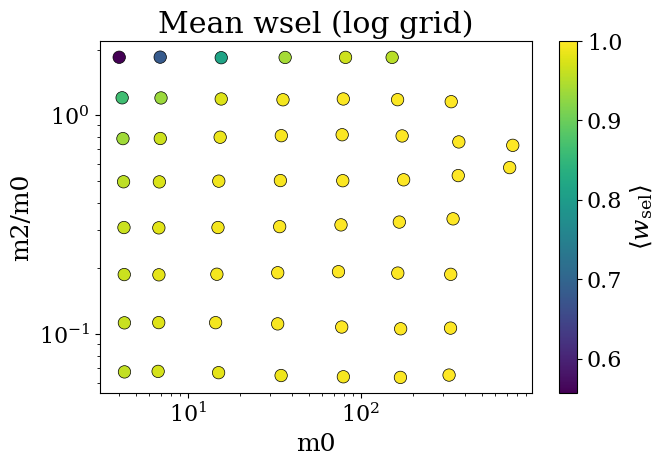

In [72]:
# 2D scatter plot of mean(wsel) on log-spaced grid
wsel_grid_log = np.full((ngrid, ngrid), np.nan)
for ix in range(ngrid):
    for iy in range(ngrid):
        sel = (i_m0_log == ix) & (i_tr_log == iy)
        n = np.sum(sel)
        if n < 10:
            continue
        wsel_grid_log[ix, iy] = np.mean(w[sel])

valid_wsel = ~np.isnan(wsel_grid_log)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    m0_center_log[valid_wsel], trace_center_log[valid_wsel],
    c=wsel_grid_log[valid_wsel], s=80,
    cmap="viridis", edgecolors="k", linewidths=0.5,
)
plt.colorbar(sc, ax=ax, label=r"$\langle w_{\rm sel} \rangle$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("m0")
ax.set_ylabel("m2/m0")
ax.set_title(f"Mean wsel (log grid)")
plt.tight_layout()


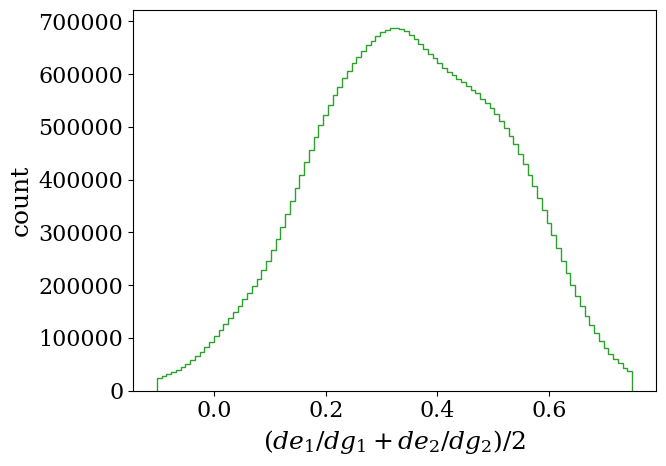

In [83]:
fig, ax = plt.subplots(figsize=(7, 5))
p_lo, p_hi = np.percentile(wde_avg, [0.5, 99.5])
ax.hist(resp_per_obj, bins=100, range=(p_lo, p_hi), histtype="step", color="C2", lw=1.5)
ax.set_xlabel(r"$(de_1/dg_1 + de_2/dg_2)/2$")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

SVR training bins (m0<100.0, 0.05<m2/m0<1.0): 30
Data-only bins   (outside window): 27
SVR (RBF) response model:
  R^2 score    = 0.999916
  residual std = 0.001090
  residual max = 0.001519


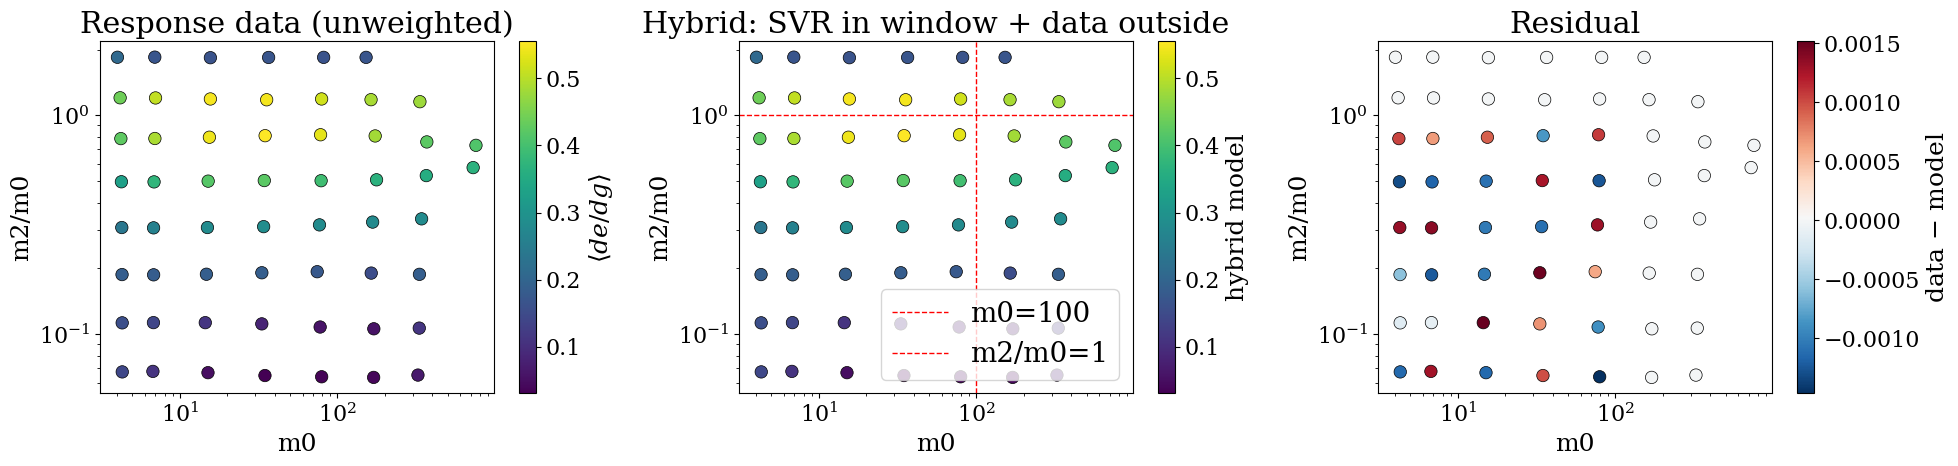

In [74]:
# Model UNWEIGHTED response with SVR for m0 < M0_SVR_MAX and
# TRACE_MIN < m2/m0 < TRACE_MAX. Outside that window we return the
# object's own measured response.
import pickle

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

M0_SVR_MAX = 100.0
TRACE_MIN = 0.05
TRACE_MAX = 1.0

valid_resp = ~np.isnan(resp_only_grid_log)
train_mask = (
    valid_resp
    & (m0_center_log < M0_SVR_MAX)
    & (trace_center_log > TRACE_MIN)
    & (trace_center_log < TRACE_MAX)
)

y_resp_all = resp_only_grid_log[valid_resp]
m0_f_all = m0_center_log[valid_resp]
tr_f_all = trace_center_log[valid_resp]

y_resp = resp_only_grid_log[train_mask]
m0_f = m0_center_log[train_mask]
tr_f = trace_center_log[train_mask]
wt_resp = count_grid_log[train_mask].astype(float)

print(
    f"SVR training bins (m0<{M0_SVR_MAX}, "
    f"{TRACE_MIN}<m2/m0<{TRACE_MAX}): {train_mask.sum()}"
)
print(
    f"Data-only bins   (outside window): "
    f"{(valid_resp & ~train_mask).sum()}"
)

X_raw = np.column_stack([np.log10(m0_f), np.log10(tr_f)])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

svr = SVR(kernel="rbf", C=100, epsilon=0.001, gamma="scale")
svr.fit(X_scaled, y_resp, sample_weight=wt_resp)

y_pred_train = svr.predict(X_scaled)
resid_train = y_resp - y_pred_train
print("SVR (RBF) response model:")
print(f"  R^2 score    = {svr.score(X_scaled, y_resp, sample_weight=wt_resp):.6f}")
print(f"  residual std = {np.std(resid_train):.6f}")
print(f"  residual max = {np.max(np.abs(resid_train)):.6f}")


def predict_response(m0_val, trace_val, response):
    """Per-object response prediction.

    SVR is used for objects with m0 < M0_SVR_MAX AND
    TRACE_MIN < m2/m0 < TRACE_MAX. Everywhere else we return the
    object's own measured ``response`` unchanged.
    """
    m0_val = np.asarray(m0_val)
    trace_val = np.asarray(trace_val)
    response = np.asarray(response)
    out = np.array(response, dtype=np.float64, copy=True)

    svr_mask = (
        (m0_val > 1e-5)
        & (m0_val < M0_SVR_MAX)
        & (trace_val > TRACE_MIN)
        & (trace_val < TRACE_MAX)
    )
    if np.any(svr_mask):
        X_s = scaler.transform(
            np.column_stack([
                np.log10(m0_val[svr_mask]),
                np.log10(trace_val[svr_mask]),
            ])
        )
        out[svr_mask] = svr.predict(X_s)
    return out


def save_predict_response(fname):
    """Pickle the trained SVR, scaler and window parameters."""
    payload = {
        "svr": svr,
        "scaler": scaler,
        "m0_svr_max": M0_SVR_MAX,
        "trace_min": TRACE_MIN,
        "trace_max": TRACE_MAX,
    }
    with open(fname, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved predict_response to {fname}")


# Hybrid prediction on the grid centers (for the imshow below)
y_hybrid_all = predict_response(m0_f_all, tr_f_all, y_resp_all)
resid_all = y_resp_all - y_hybrid_all

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
vmin_r = min(y_resp_all.min(), y_hybrid_all.min())
vmax_r = max(y_resp_all.max(), y_hybrid_all.max())

ax = axes[0]
sc = ax.scatter(m0_f_all, tr_f_all, c=y_resp_all, s=80,
                cmap="viridis", edgecolors="k", linewidths=0.5,
                vmin=vmin_r, vmax=vmax_r)
plt.colorbar(sc, ax=ax, label=r"$\langle de/dg \rangle$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("m0"); ax.set_ylabel("m2/m0")
ax.set_title("Response data (unweighted)")

ax = axes[1]
sc = ax.scatter(m0_f_all, tr_f_all, c=y_hybrid_all, s=80,
                cmap="viridis", edgecolors="k", linewidths=0.5,
                vmin=vmin_r, vmax=vmax_r)
plt.colorbar(sc, ax=ax, label="hybrid model")
ax.axvline(M0_SVR_MAX, color="r", ls="--", lw=1, label=f"m0={M0_SVR_MAX:g}")
ax.axhline(TRACE_MAX, color="r", ls="--", lw=1, label=f"m2/m0={TRACE_MAX:g}")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("m0"); ax.set_ylabel("m2/m0")
ax.set_title("Hybrid: SVR in window + data outside")
ax.legend()

ax = axes[2]
sc = ax.scatter(m0_f_all, tr_f_all, c=resid_all, s=80,
                cmap="RdBu_r", edgecolors="k", linewidths=0.5)
plt.colorbar(sc, ax=ax, label=r"data $-$ model")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("m0"); ax.set_ylabel("m2/m0")
ax.set_title("Residual")

plt.tight_layout()
plt.show()


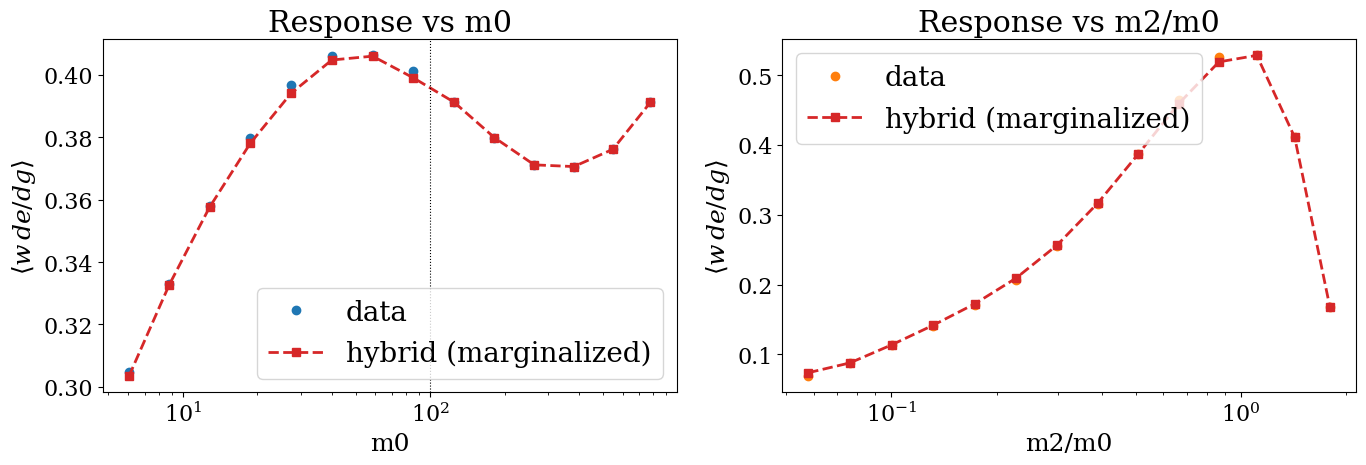

In [75]:
# 1D model comparison: marginalize model the same way as data
# Per object: SVR for m0<100, raw response for m0>=100.
resp_model_all = predict_response(m0_cut, trace_cut, resp_per_obj)

# Model vs m0 (marginalize over trace)
model_vs_m0 = np.full(nbins_1d, np.nan)
for ib in range(nbins_1d):
    sel = i_m0_1d == ib
    if np.sum(sel) < 100:
        continue
    model_vs_m0[ib] = np.mean(w[sel] * resp_model_all[sel])

# Model vs m2/m0 (marginalize over m0)
model_vs_tr = np.full(nbins_1d, np.nan)
for ib in range(nbins_1d):
    sel = i_tr_1d == ib
    if np.sum(sel) < 100:
        continue
    model_vs_tr[ib] = np.mean(w[sel] * resp_model_all[sel])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
valid_m0 = ~np.isnan(resp_vs_m0)
ax.plot(m0_centers_1d[valid_m0], resp_vs_m0[valid_m0], "o", color="C0", label="data")
valid_mod = ~np.isnan(model_vs_m0)
ax.plot(m0_centers_1d[valid_mod], model_vs_m0[valid_mod], "s--", color="C3", label="hybrid (marginalized)")
ax.axvline(M0_SVR_MAX, color="k", ls=":", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel("m0"); ax.set_ylabel(r"$\langle w \, de/dg \rangle$")
ax.set_title("Response vs m0"); ax.legend()

ax = axes[1]
valid_tr = ~np.isnan(resp_vs_tr)
ax.plot(tr_centers_1d[valid_tr], resp_vs_tr[valid_tr], "o", color="C1", label="data")
valid_mod = ~np.isnan(model_vs_tr)
ax.plot(tr_centers_1d[valid_mod], model_vs_tr[valid_mod], "s--", color="C3", label="hybrid (marginalized)")
ax.set_xscale("log")
ax.set_xlabel("m2/m0"); ax.set_ylabel(r"$\langle w \, de/dg \rangle$")
ax.set_title("Response vs m2/m0"); ax.legend()

plt.tight_layout()
plt.show()

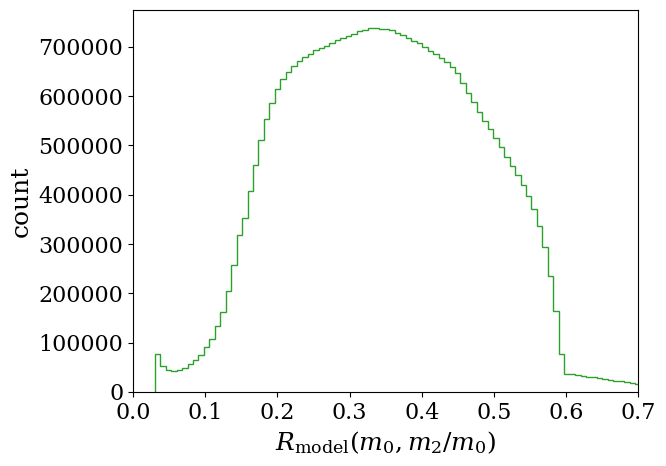

In [85]:
# Histogram of wsel * R_model (R from SVR)
wR = resp_model_all

#wR = w * resp_model_all
p_lo, p_hi = np.percentile(wR, [0.1, 99.9])

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(wR, bins=100, range=(p_lo, p_hi), histtype="step", color="C2", lw=1.5)
ax.set_xlabel(r"$R_{\rm model}(m_0, m_2/m_0)$")
ax.set_ylabel("count")
ax.set_xlim(0.0, 0.7)
plt.tight_layout()
plt.show()

In [79]:
save_predict_response("response_model.pkl")

Saved predict_response to response_model.pkl
